### 순차 데이터
- 텍스트 데이터 : ex) I am a boy, 순서가 의미가 있다.
- 시계열 데이터: 주식

### 순환 신경망(RNN: Recurrent Neural Network)

#### IMDB
- Internet Movie Data Base
- 영화를 시청하고 나온 긍정/부정 데이터의 합
- 구성: 
- Train(25000개 중 긍정(12500)/ 부정(12500))로 구성
-  Test(25000개 중 긍정(12500)/ 부정(12500))로 구성
- NLP: Natural Language Process(자연어 처리)
- 말뭉치: 하나의 데이터 셋을 의미 # 말뭉치마다 크기가 다르기 때문에 데이터 셋이라 부르지 않음
- 토큰: 하나의 단어를 의미
- 어휘사전: 번호(숫자)로 구분된 유일한 단어들의 집합

#### keras로 IMDB 불러오기
- IMDB는 어휘사전으로 변환되어 있음

In [1]:
from tensorflow.keras.datasets import imdb

In [2]:
 (train_input, train_target), (test_input, test_target) = \
    imdb.load_data(num_words=500) # 500개의 단어만 사용

In [3]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(25000,) (25000,)
(25000,) (25000,)


In [4]:
# train의 첫번째 문장의 Token 갯수
len(train_input[0])

218

In [5]:
# train의 두번째 문장의 Token 갯수
len(train_input[1])

189

영화에 대한 댓글 길이가 다르다.

In [6]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


- 모든 샘플의 시작 부분의 토큰은 1을 사용
- 2는 선정한 단어 갯수(num_words=500)에 포함되지 않은 단어
- train_input 자체는 넘파이 배열이나 사용자마다 댓글의 토큰수가 다르기 때문에 넘파이 배열을 사용하지 못하고 List를 사용

In [7]:
# train_target 출력
print(train_target[:10]) # 1: 긍정, 0: 부정

[1 0 0 1 0 0 1 0 1 0]


#### 훈련세트 준비

In [8]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = \
    train_test_split(
        train_input,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [9]:
print(train_input.shape, train_target.shape)
print(val_input.shape, val_target.shape)

(20000,) (20000,)
(5000,) (5000,)


#### 각 리뷰마다 문자길이 시각화

In [10]:
import numpy as np

In [11]:
trainLength = []
for i in train_input:
    trainLength.append(len(i))
    
np.array(trainLength)

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

In [12]:
# List Comprehension
totalLength = np.array([len(i) for i in train_input])

totalLength

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

#### List Comprehension Exercise

In [13]:
# 0부터 9까지의 숫자 중 짝수만 List에 추가하기
nList = [i for i in range(10) if i % 2 == 0]
nList

[0, 2, 4, 6, 8]

In [14]:
import matplotlib.pyplot as plt

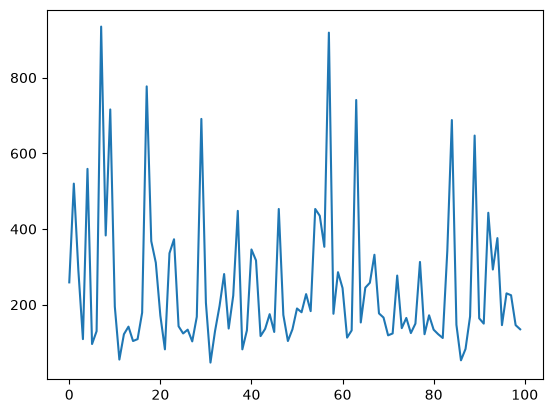

In [15]:
plt.plot(totalLength[:100])
plt.show()

#### Sequence Padding
: 전체 자릿수를 100이로 가정, 한 문장에 토큰이 3인 경우 나머지(97)는 0으로 채운다

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [17]:
print(train_seq.shape, val_seq.shape)

(20000, 100) (5000, 100)


In [18]:
print(train_seq[0])

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [19]:
# 원 핫 인코딩
from tensorflow import keras

train_oh = keras.utils.to_categorical(train_seq)
val_oh = keras.utils.to_categorical(val_seq)

In [20]:
train_oh[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 500))

In [21]:
model = keras.Sequential()

model.add(
    keras.layers.SimpleRNN(
        8,
        input_shape = [100, 500]
    )
)

model.add(
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
)

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# loss 함수
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics = ['accuracy']
)

In [23]:
# 최적의 함수 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_rnn_imdb.keras')

# Epoch 실행 횟수 저장
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
) 

In [24]:
history = model.fit(
    train_oh,
    train_target,
    epochs=100,
    batch_size=64,
    validation_data= (val_oh, val_target),
    callbacks= [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6898 - loss: 0.5886 - val_accuracy: 0.7164 - val_loss: 0.5562
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7745 - loss: 0.4845 - val_accuracy: 0.7582 - val_loss: 0.5283
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7928 - loss: 0.4542 - val_accuracy: 0.7786 - val_loss: 0.4634
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7977 - loss: 0.4425 - val_accuracy: 0.7838 - val_loss: 0.4564
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8038 - loss: 0.4315 - val_accuracy: 0.7698 - val_loss: 0.4776
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8090 - loss: 0.4229 - val_accuracy: 0.7814 - val_loss: 0.4718
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8089 - loss: 0.4163 - val_accuracy: 0.7728 - val_loss: 0.4837


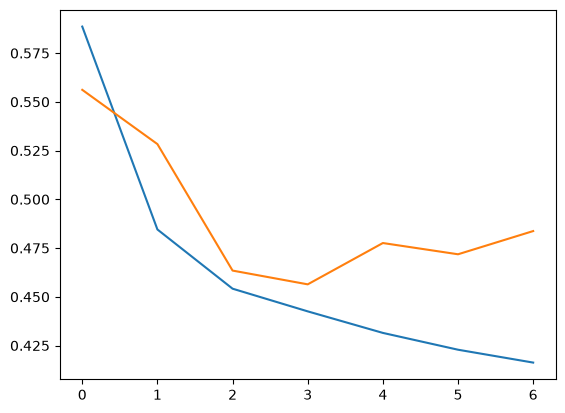

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

#### LSTM

In [35]:
model = keras.Sequential()

# 첫 레이어의 input_shape를 1차원 (100,) 형태로 수정합니다.
model.add(keras.layers.Embedding(input_dim=500, output_dim=16, input_shape=(100,)))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

# 💡 질문하신 코드를 그대로 유지하여 실행합니다. 이제 에러 없이 작동합니다!
model.build(
    input_shape=(None, 100)
)

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
# loss 함수
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics = ['accuracy']
)

In [37]:
# 최적의 함수 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_rnn_imdb.keras')

# Epoch 실행 횟수 저장
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
) 

In [38]:
history = model.fit(
    train_seq, # 원 핫 인코딩 불필요
    train_target,
    epochs=100,
    batch_size=64,
    validation_data= (val_seq, val_target),
    callbacks= [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6622 - loss: 0.6184 - val_accuracy: 0.7496 - val_loss: 0.5230
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7553 - loss: 0.5066 - val_accuracy: 0.7490 - val_loss: 0.5155
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7805 - loss: 0.4695 - val_accuracy: 0.7450 - val_loss: 0.5019
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7861 - loss: 0.4516 - val_accuracy: 0.7800 - val_loss: 0.4615
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7946 - loss: 0.4378 - val_accuracy: 0.7986 - val_loss: 0.4325
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7979 - loss: 0.4313 - val_accuracy: 0.7400 - val_loss: 0.5145
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8049 - loss: 0.4235 - val_accuracy: 0.7684 - val_loss: 0.5008
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8091 - loss: 0.4178 - 